In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
movie=pd.read_csv("/content/IMDb Movies India.csv",encoding="latin1")

In [ ]:
movie.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

In [ ]:
movie.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [ ]:
movie.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


In [ ]:
movie.shape

(15509, 10)

In [ ]:
movie["Year"]=movie["Year"].fillna("Undefined")
movie["Duration"]=movie["Duration"].fillna("Undefined")
movie["Genre"]=movie["Genre"].fillna("Unknown")
movie["Votes"]=movie["Votes"].fillna("Not Mentioned")
movie["Director"]=movie["Director"].fillna("Unknown")

1. Introduction

What is a T-Test?

A T-Test is a statistical hypothesis test used to determine whether there is a significant difference between the means of one or more groups. It helps us decide whether an observed difference is likely due to chance or represents a real effect in the population.

T-Tests are widely used when working with small to moderate sample sizes and when the population standard deviation is unknown.

Why Do We Use a T-Test?

The primary purpose of a T-Test is to compare averages and make data-driven decisions.

Some common applications include:

Comparing a sample mean to a known value.
Comparing the means of two independent groups.
Comparing measurements taken before and after an intervention.
Determining whether observed differences are statistically significant.

Examples:

Do Drama and Comedy movies have different average ratings?
Did students score higher after training?
Is the average movie rating different from 6?

Assumptions of a T-Test

Before applying a T-Test, the following assumptions should be checked:

Independence of Observations
Each observation should be independent of the others.
Normality
The data should be approximately normally distributed.
This can be checked using:
Histogram
Q-Q Plot
Shapiro-Wilk Test
Continuous Data
The variable being analyzed should be numerical and continuous.
Equal Variance (for Independent T-Tests)
The variances of the groups should be approximately equal.
This assumption can be tested using Levene's Test.

| T-Test Type        | Purpose                                          | Example                                 |
| ------------------ | ------------------------------------------------ | --------------------------------------- |
| One-Sample T-Test  | Compare a sample mean to a known value           | Is the average movie rating equal to 6? |
| Independent T-Test | Compare means of two different groups            | Drama vs Comedy ratings                 |
| Paired T-Test      | Compare the same group before and after an event | Before vs After training scores         |


Before applying a T-Test, we often check whether the data is approximately normally distributed.

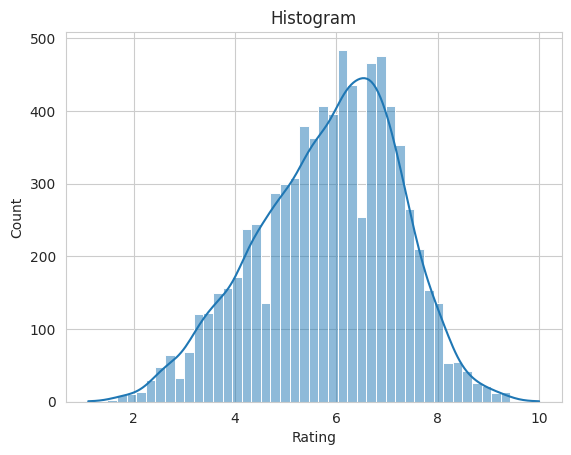

In [3]:
sns.histplot(movie["Rating"],kde=True)
plt.title("Histogram")
plt.show()

The histogram suggests that movie ratings are approximately normally distributed, as the distribution exhibits a bell-shaped pattern with a single central peak.

However, visual inspection alone is insufficient. Therefore, a formal normality test (Shapiro-Wilk Test) and a Q-Q Plot are used to further assess the normality assumption.

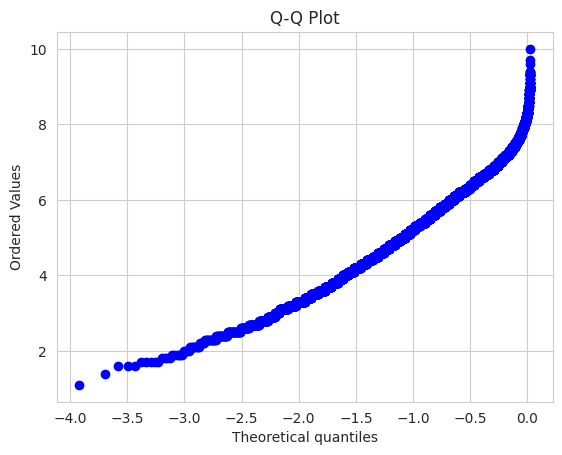

In [ ]:
from scipy.stats import probplot

probplot(
    movie["Rating"],plot=plt
)

plt.title("Q-Q Plot")
plt.show()

The Q-Q plot shows noticeable deviation from a straight line, particularly in the upper tail of the distribution.

This suggests that the movie ratings are not perfectly normally distributed and exhibit departures from normality.

Do Drama and Comedy movies have significantly different average ratings?

H₀: The average rating of Drama and Comedy movies is the same.

H₁: The average rating of Drama and Comedy movies is different.

In [ ]:
drama = movie[
    movie["Genre"].str.contains("Drama", na=False)
]["Rating"]

comedy = movie[
    movie["Genre"].str.contains("Comedy", na=False)
]["Rating"]

print(" Average Drama=",drama.mean())
print(" Average Comedy=",comedy.mean())
print(" Total Drama=",drama.count())
print(" Total Comedy=",comedy.count())

 Average Drama= 5.998558082859464
 Average Comedy= 5.7372902423865755
 Total Drama= 4924
 Total Comedy= 1609


### Observation

The average rating of Drama movies is approximately 6.00, whereas the average rating of Comedy movies is approximately 5.74.

Based on the sample means, Drama movies appear to receive slightly higher ratings than Comedy movies.

The dataset contains 4,924 Drama movies and 1,609 Comedy movies, providing sufficient observations for conducting an Independent T-Test.

In [ ]:
from scipy.stats import ttest_ind

stat,p = ttest_ind(
    drama,
    comedy,
    nan_policy="omit"
)

print("T-statistic =", stat)
print("P-value =", p)

T-statistic = 6.826755842549046
P-value = 9.468220618010193e-12


## Limitations

- The sample sizes of Drama and Comedy movies are not equal.
- Ratings may be influenced by factors other than genre.
- The data is observational and does not imply causation.
- The normality assumption is only approximately satisfied.

Using α = 0.05

### Independent T-Test Results

T-statistic = 6.827

P-value = 9.47 × 10⁻¹²

Since the p-value is less than the significance level (0.05), the null hypothesis is rejected.

There is sufficient statistical evidence to conclude that Drama and Comedy movies have significantly different average ratings.

The average Drama movie rating (5.999) is higher than the average Comedy movie rating (5.737).

In [ ]:
alpha=0.05

if p < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Reject the null hypothesis


CONCLUSION:
In this notebook, I explored the fundamentals of hypothesis testing using Python and applied an Independent Two-Sample T-Test to compare the average ratings of Drama and Comedy movies.

Key Findings
Average Drama Rating = 5.999
Average Comedy Rating = 5.737
T-Statistic = 6.827
P-Value = 9.47 × 10⁻¹²

Using a significance level of α = 0.05, the p-value was significantly smaller than α.

THEREFORE:
Reject the Null Hypothesis (H₀)

This indicates that there is sufficient statistical evidence to conclude that the average ratings of Drama and Comedy movies are significantly different.

The analysis also showed that Drama movies tend to receive higher ratings on average compared to Comedy movies in this dataset.
